In [85]:
import numpy as np
import matplotlib.pyplot as plt

## Particle Decay
A radioactive source emits $N$ unstable particles. The particles are emitted at constant speed along the $x$ axis. For each particle, indexed by  $i\in\{1,\dots,N\}$, we mark the  position $x_i$ where it decays. 

We know that the probability density of decaying at $x$ is 
\begin{equation}
P(x|\lambda)=\frac{1}{\lambda}e^{-x/\lambda},
\end{equation}

for an unknown parameter $\lambda$.

Given $\mathbf x=(x_1,\dots,x_N)$ our objective is to estimate $\lambda$

In [86]:
lambda_star=1 #true value of the parameter we use to generate the data. Also said "ground truth"
N=1000

In [87]:
np.random.seed(123)
x=np.random.exponential(scale=lambda_star,size=N) #generate data

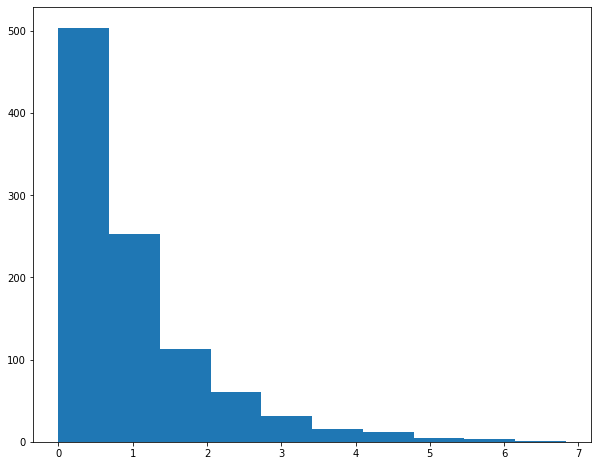

In [88]:
#plot data
plt.figure(figsize=(10,8))
plt.hist(x);
#plt.yscale('log')
#this indeed looks like an exponential distribution

#### Log likelihood computation
$\ell(\lambda)=\log P(\mathbf x|\lambda)=\sum_{i=1}^N \log P(x_i|\lambda)=-N\log\lambda-\frac{1}{\lambda}\sum_{i=1}^N x_i $


In [89]:
def log_likelihood_exp(lambd,x): #log likelihood of the exponential distribution
    l=-np.sum(np.log(lambd)+x/lambd)
    return l

Text(0, 0.5, 'log likelihood')

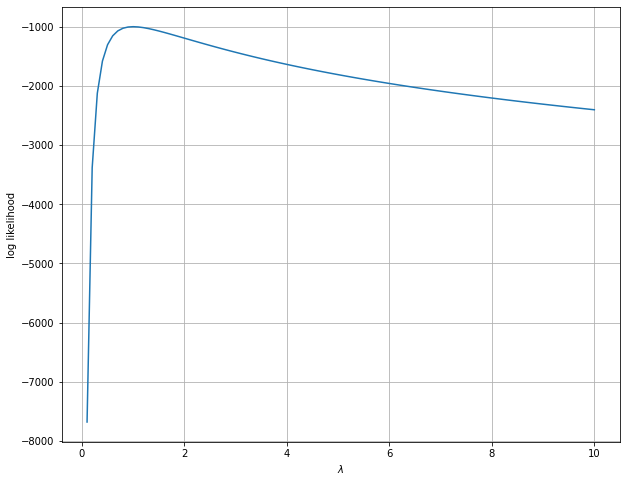

In [90]:
lambda_range=np.linspace(1e-1,10,100)
log_likelihood_values=[log_likelihood_exp(lambd,x) for lambd in lambda_range]
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(lambda_range,log_likelihood_values)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"log likelihood")
#visual check: the maximum of the likelihood is indeed near lambda=1

Now maximize the log likelihood using one of the scipy built in optimizers

In [91]:

from scipy.optimize import minimize

In [92]:
def neg_log_likelihood_exp(lambd,x): #scipy only minimizes so we must define the log likelihood with the sign changed
    return -log_likelihood_exp(lambd,x)

In [93]:
opt_result=minimize(neg_log_likelihood_exp,x0=1e-2,args=(x)) # minimize -log_likelohood
opt_result 
#the argmax is the last output 'x:...'
#Notice the maximum is indeed near lambda_star=1 (should be around 0.99)

      fun: 998.3045399332606
 hess_inv: array([[0.00099696]])
      jac: array([-7.62939453e-06])
  message: 'Optimization terminated successfully.'
     nfev: 39
      nit: 7
     njev: 13
   status: 0
  success: True
        x: array([0.99830597])

Now introduce the prior distribution $P(\lambda)=\frac{1}{\lambda_0}e^{-\lambda/\lambda_0}$ with $\lambda_0=0.1$. Then we carry out MAP estimation

 Since the true value of lambda is 1 ($\lambda^*=1$) this means the prior is deceiving us. For small sample sizes we will observe that the MAP estimator will be close to 0.1, instead when we increase the number of samples, the effect of the prior will be washed out, and the MAP estimator will be close to the Maximum likelihood one.

In [94]:
lambda0=0.1 
def prior_lambda(lambd,lambda0):
    return np.exp(-lambd/lambda0)/lambda0

Compute the unnormalized log poterior (we want to maximize it so the normalization is not important)

In [95]:
def log_posterior(lambd, lambda0,x):
    return log_likelihood_exp(lambd,x)+np.log(prior_lambda(lambd,lambda0))

Text(0, 0.5, '$\\log [P(\\mathbf{x}|\\lambda)P(\\lambda)]$')

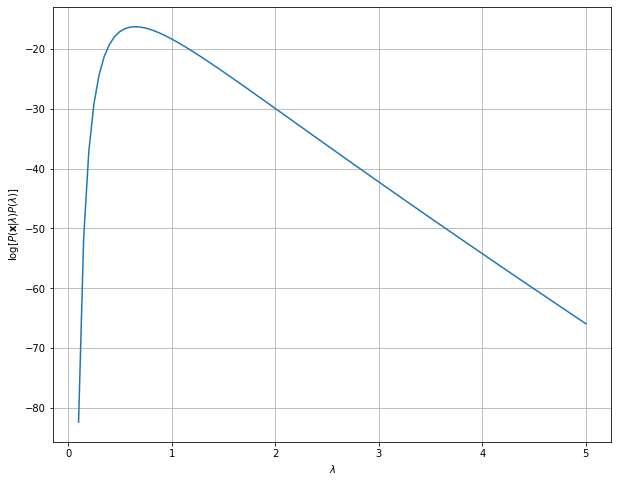

In [96]:
lambda_range=np.linspace(1e-1,5,100)
#if we use a restricted number of samples (10) the effect of the prior is more evident
log_posterior_values=[log_posterior(lambd,lambda0,x[:10]) for lambd in lambda_range]
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(lambda_range,log_posterior_values)
plt.xlabel(r'$\lambda$')
plt.ylabel(r"$\log [P(\mathbf{x}|\lambda)P(\lambda)]$")
#notice how the maximum is shifted towards 0.1. If now we increase the number of samples (e.g. replace x[:10] with x[:70]) the estimator will approach the amximum likelihood one.

In [97]:
def neg_log_posterior(lambd,lambd0,x):
    return -log_posterior(lambd,lambda0,x)

In [98]:
opt_result=minimize(neg_log_posterior,x0=1,args=(lambda0,x),method='Powell') # minimize -log_likelohood
opt_result 
#here we use all the 100 samples 
#the last entry called x is the MAP estimator

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log
  


   direc: array([[1.]])
     fun: array(1005.93583572)
 message: 'Optimization terminated successfully.'
    nfev: 14
     nit: 1
  status: 0
 success: True
       x: array(0.98849701)

## Bent coin
Now repeat the previous computations in the case of the bent coin example
let $\mathbf s=(s_1,\dots,s_N)$ be a vector with i.i.d components , with $x_i\in\{0,1\} \;\; \forall i$, sampled from
\begin{equation}
P(s|p)=p^s(1-p)^{1-s}
\end{equation}


In [99]:
np.random.seed(123)
p_star=0.1 #ground truth
N=1000 #number of samples
np.random.seed(12)

In [100]:
# Generate the data s=(s_1,...,s_N) from the probability measure above with p=p_star, and print the first 10 samples s_1,...s_10

In [101]:
#@title
s=np.random.binomial(1,p=p_star,size=N)
s[:10]

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0])

In [102]:
#define the log_likelihood function following this prototype
def log_likelihood(p,s): #p is a scalar, while s is a 1D numpy array of arbitrary length
    pass
    

In [103]:
#@title
def log_likelihood(p,s): #p is a scalar, while s is a 1D numpy array of arbitrary length
    l=np.sum(s)*np.log(p/(1-p))+N*np.log(1-p)
    return l

In [104]:
#plot the log_likelihood as a function of p between 0 and 1
#careful when choosing the values of p, the log_likelihood may blow up!

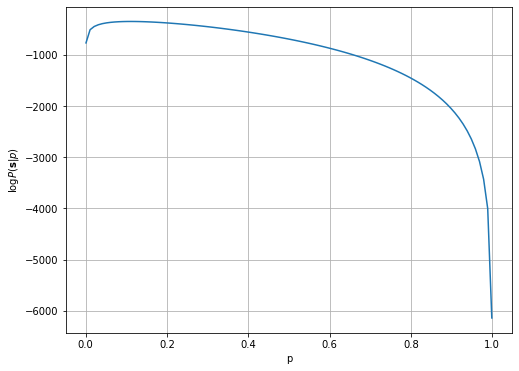

In [105]:
#@title
p_values=np.linspace(1e-3,1-1e-3,100) #use these as values for the x_axis
plt.figure(figsize=(8,6))
plt.plot(p_values,log_likelihood(p_values,s))
plt.xlabel('p')
plt.ylabel(r'$\log P( \mathbf{s}|p)$')
plt.grid()
#notice how the maximum is near 0.1 which is the value of p_star

Now add the prior $P(p)=6p(1-p)$ As in the particle decay example, this prior is actually deceiving since it has a maximum in $p=0.5$

In [106]:
def prior(p):
    return 6*p*(1-p)

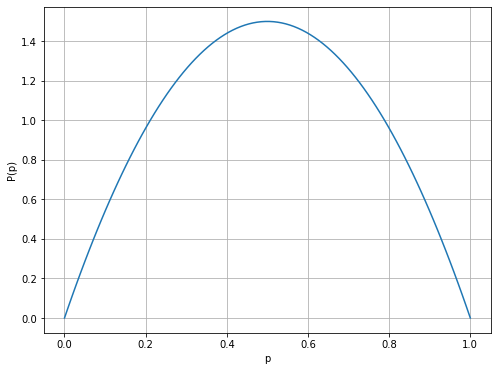

In [107]:
p_values=np.linspace(0,1,100)
plt.figure(figsize=(8,6))
plt.plot(p_values,prior(p_values))
plt.xlabel("p")
plt.ylabel("P(p)")
plt.grid()

In [108]:
#The posterior distribution is P(p|s)=P(s|p)P(p)/P(s). Ignore the normalization P(p) and compute the logarithm of the posterior.

In [109]:
def log_posterior(p,s):
    pass

In [110]:
#@title
def log_posterior(p,s):
    return log_likelihood(p,s)+np.log(prior(p))

In [111]:
#plot the log posterior as a function of p

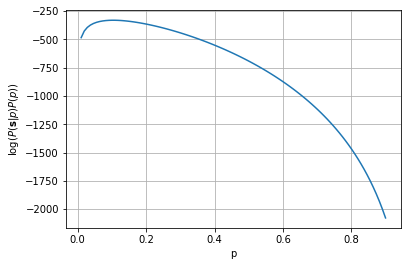

In [112]:
#@title
p_values=np.linspace(1e-2,1-1e-1,100) #use these as values for the x_axis
plt.plot(p_values,log_posterior(p_values,s[:900]))
plt.xlabel('p')
plt.ylabel(r'$\log(P(\mathbf{s}|p)P(p))$')
plt.grid()

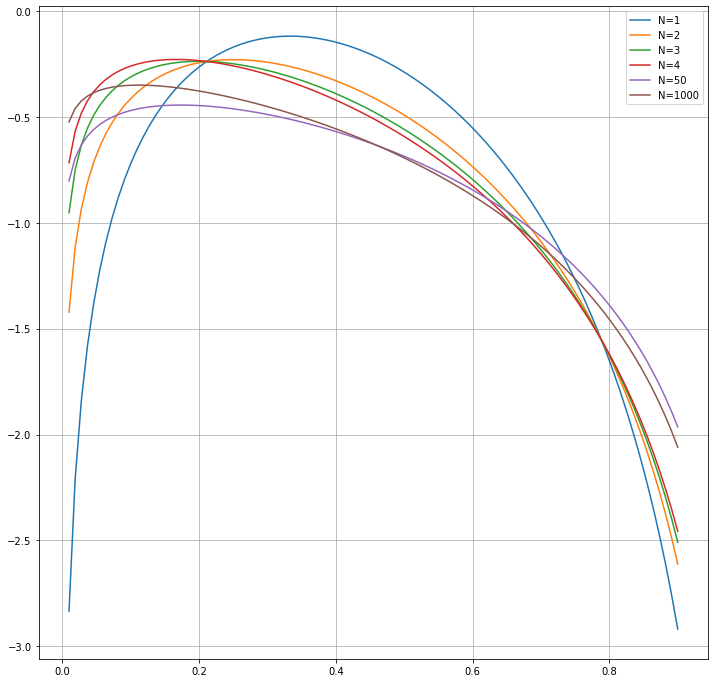

In [113]:
# Look at how the MAP estimator approaches the Maximum likelihood one as N tends to infinity
p_star=0.1
p_values=np.linspace(1e-2,1-1e-1,100) 
plt.figure(figsize=(12,12))
for N in [1,2,3,4,50,1000]:
    plt.plot(p_values,log_posterior(p_values,s[:N])/N,label="N=%d"%N)
plt.legend()
plt.grid()